#  Customer Churn Prediction + Retention Decision System

---

## 1.  Problem Understanding

### Objective
We aim to build a system that:
- Predicts whether a customer will churn
- Identifies key drivers of churn
- Translates predictions into business actions

### Business goal
Reduce customer churn by prioritizing retention efforts on high-risk customers.

---
## 2.  Load Dataset

- Load Telco Customer Churn dataset
- Inspect structure and features

In [1]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Inspect the first few rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


---
## 3.  Data Understanding (EDA)

### 3.1 Dataset overview
### 3.2 Target analysis
### 3.3 Feature categorization

In [2]:
# 3.1 Dataset overview
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

# 3.2 Target analysis
print("\nChurn Distribution:\n", df['Churn'].value_counts(normalize=True))

# 3.3 Categorical vs Numerical features
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numeric_cols = df.select_dtypes(exclude=['object']).columns.tolist()

Shape: (7043, 21)

Data Types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract          

---
## 4.  Exploratory Data Analysis

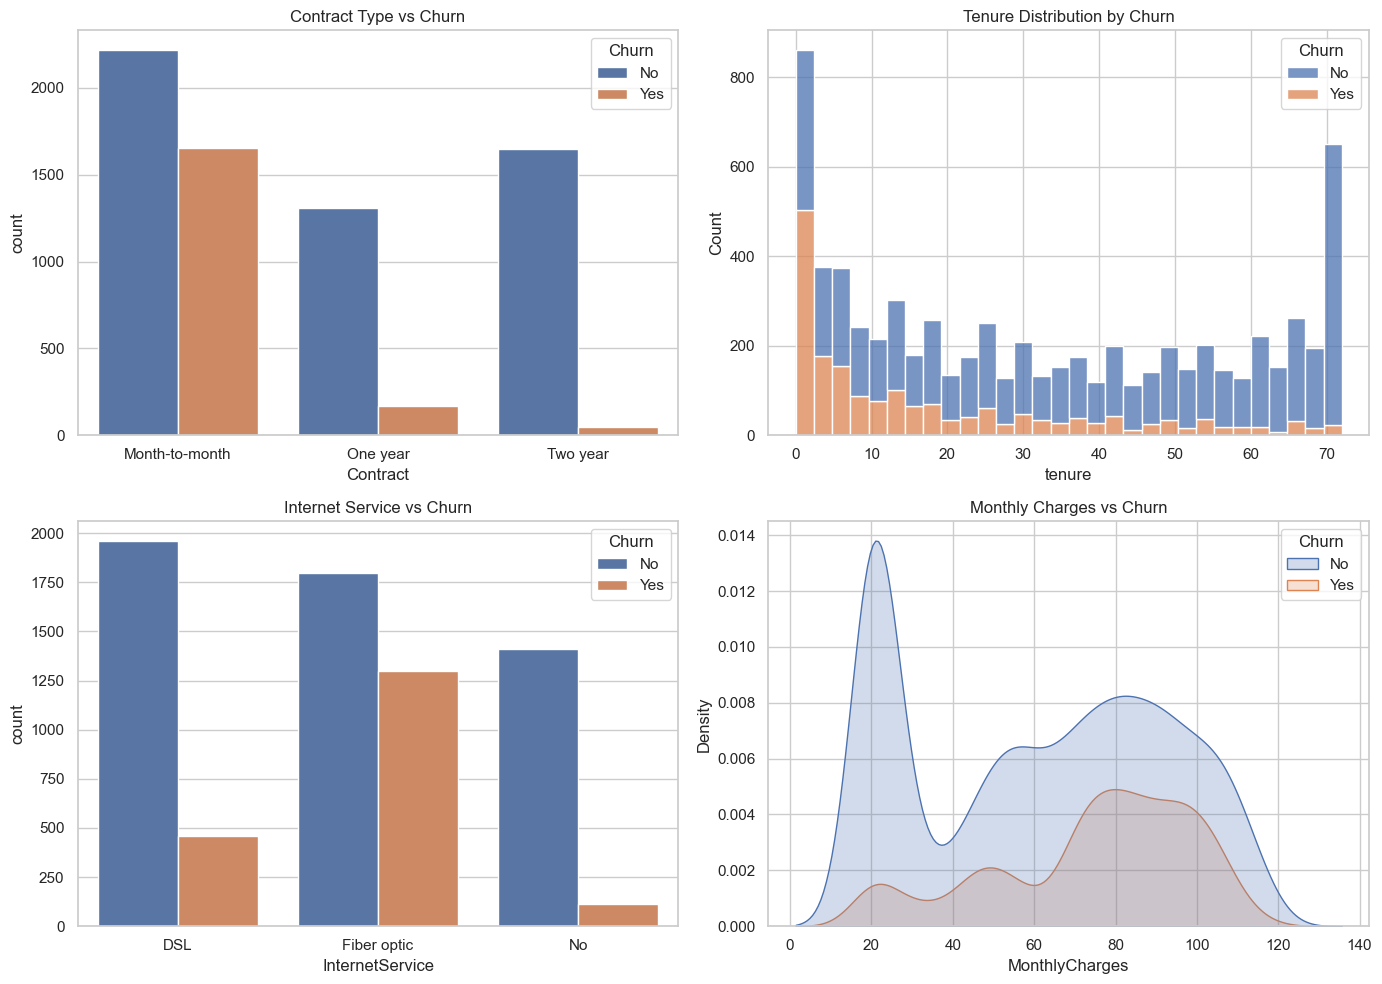

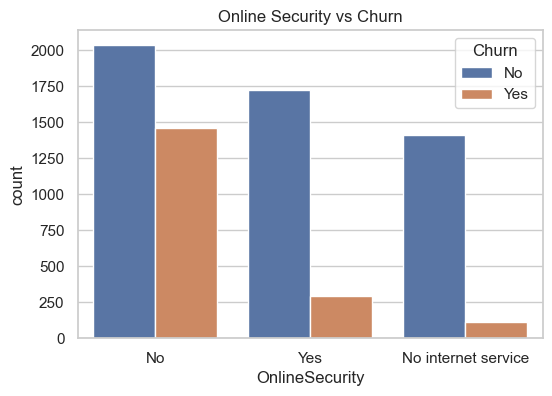

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot configurations
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 4.1 Contract vs Churn
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0, 0])
axes[0, 0].set_title('Contract Type vs Churn')

# 4.2 Tenure vs Churn
sns.histplot(data=df, x='tenure', hue='Churn', multiple="stack", ax=axes[0, 1], bins=30)
axes[0, 1].set_title('Tenure Distribution by Churn')

# 4.3 Internet Service vs Churn
sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[1, 0])
axes[1, 0].set_title('Internet Service vs Churn')

# 4.4 Monthly Charges vs Churn
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, ax=axes[1, 1])
axes[1, 1].set_title('Monthly Charges vs Churn')

plt.tight_layout()
plt.show()

# 4.5 Online Security vs Churn
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='OnlineSecurity', hue='Churn')
plt.title('Online Security vs Churn')
plt.show()

---
## 5. Data Preprocessing

In [4]:
# 5.1 Data cleaning
# Convert TotalCharges to numeric, replace blank spaces with NaN, then fill with 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(" ", np.nan))
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Save customer IDs for later business layer prioritization before dropping
customer_ids = df['customerID'].copy()

# 5.2 Feature selection
# Drop customerID as it holds no predictive power
df.drop('customerID', axis=1, inplace=True)

# 5.4 Target encoding
# Map Churn Yes/No to 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 5.3 Encoding
# One-hot encoding for the rest of the categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

---
## 6. Train/Test Split

In [5]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Stratify=y ensures the class imbalance is preserved in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train Shape: {X_train.shape}, Test Shape: {X_test.shape}")

Train Shape: (5634, 30), Test Shape: (1409, 30)


---
## 7. Baseline Model

### Logistic Regression

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize and train baseline model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

# Evaluate Baseline
print("--- Logistic Regression Baseline ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_lr):.4f}")

--- Logistic Regression Baseline ---
Accuracy:  0.8055
Precision: 0.6572
Recall:    0.5588
F1-Score:  0.6040
ROC-AUC:   0.8427


c:\Users\Nacer\anaconda3\envs\DM_ENV\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


---
## 8. Advanced Model

### XGBoost Classifier

c:\Users\Nacer\anaconda3\envs\DM_ENV\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:41:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost Classifier ---
Accuracy:  0.7722
Precision: 0.5831
Recall:    0.4973
F1-Score:  0.5368
ROC-AUC:   0.8224


C:\Users\Nacer\AppData\Local\Temp\ipykernel_5276\951635319.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance.head(10), x='Importance', y='Feature', palette='viridis')


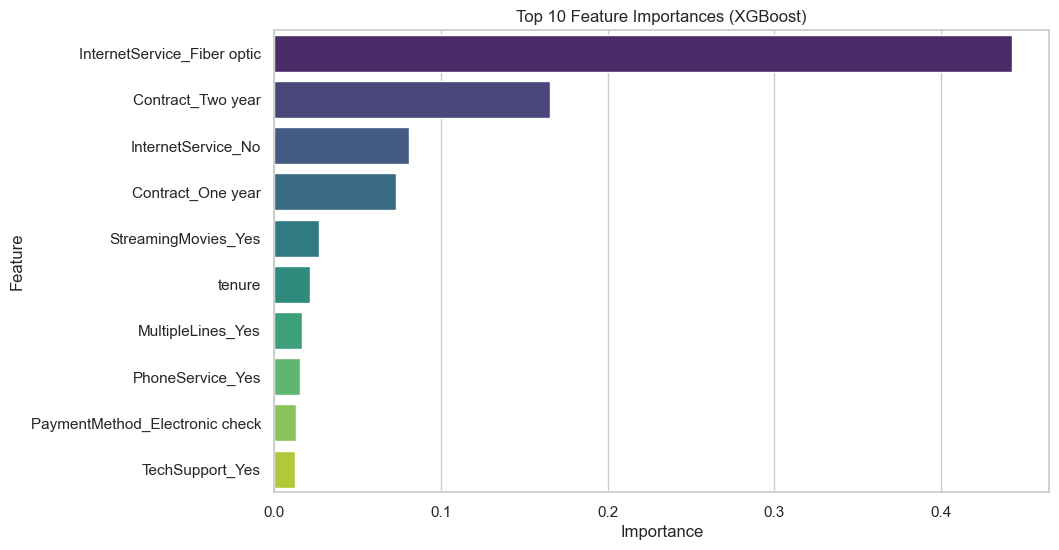

In [7]:
from xgboost import XGBClassifier

# Initialize and train XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate XGBoost
print("--- XGBoost Classifier ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_xgb):.4f}")

# Feature Importance
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Feature Importances (XGBoost)')
plt.show()

---
## 9. Model Evaluation

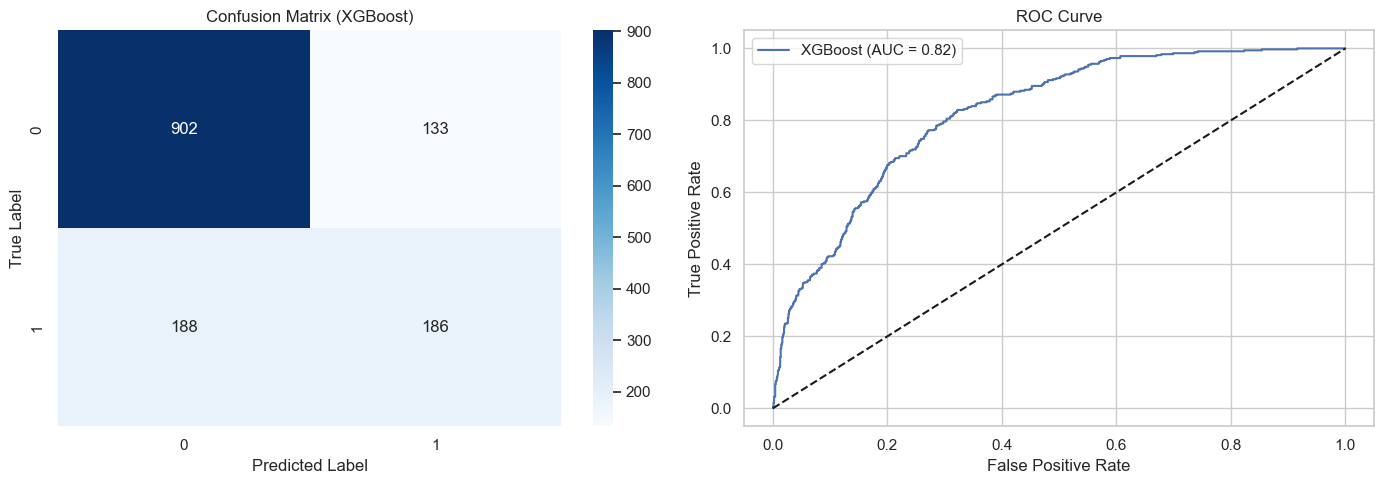

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 9.1 Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix (XGBoost)')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# 9.2 ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)
axes[1].plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.2f})')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 10. Business Decision Layer

### Risk segmentation & Action mapping

In [9]:
# Generate probabilities for the entire dataset
df_full_prob = xgb_model.predict_proba(X)[:, 1]

# Create business layer dataframe
decisions_df = pd.DataFrame({
    'CustomerID': customer_ids,
    'Churn_Risk_Prob': df_full_prob,
    'Actual_Churn': y
})

# Risk Segmentation Function
def segment_risk(prob):
    if prob >= 0.70:
        return 'High Risk'
    elif prob >= 0.40:
        return 'Medium Risk'
    else:
        return 'Low Risk'

# Action Mapping Function
def assign_action(risk):
    if risk == 'High Risk':
        return 'Send pro-active retention offer (e.g., 20% discount)'
    elif risk == 'Medium Risk':
        return 'Monitor usage and send engagement emails'
    else:
        return 'No immediate action'

decisions_df['Risk_Segment'] = decisions_df['Churn_Risk_Prob'].apply(segment_risk)
decisions_df['Recommended_Action'] = decisions_df['Risk_Segment'].apply(assign_action)

---
## 11. Customer Prioritization Output

In [10]:
# Rank customers by highest churn probability
prioritized_customers = decisions_df.sort_values(by='Churn_Risk_Prob', ascending=False)

print("Target these top 10 customers immediately:")
display(prioritized_customers.head(10))

# Segment distribution
print("\nRisk Segments Distribution:")
print(prioritized_customers['Risk_Segment'].value_counts())

Target these top 10 customers immediately:


,CustomerID,Churn_Risk_Prob,Actual_Churn,Risk_Segment,Recommended_Action
4517,2012-NWRPA,0.992816,1,High Risk,"Send pro-active retention offer (e.g., 20% dis..."
3906,6372-RFVNS,0.990880,1,High Risk,"Send pro-active retention offer (e.g., 20% dis..."
3349,0897-FEGMU,0.990484,1,High Risk,"Send pro-active retention offer (e.g., 20% dis..."
801,1450-GALXR,0.988659,1,High Risk,"Send pro-active retention offer (e.g., 20% dis..."
2831,2454-RPBRZ,0.988050,1,High Risk,"Send pro-active retention offer (e.g., 20% dis..."
1704,0107-YHINA,0.987644,1,High Risk,"Send pro-active retention offer (e.g., 20% dis..."
3822,6137-NICCO,0.986985,0,High Risk,"Send pro-active retention offer (e.g., 20% dis..."
3310,9885-CSMWE,0.986921,1,High Risk,"Send pro-active retention offer (e.g., 20% dis..."
39,8168-UQWWF,0.986855,1,High Risk,"Send pro-active retention offer (e.g., 20% dis..."
2184,4695-WJZUE,0.985585,1,High Risk,"Send pro-active retention offer (e.g., 20% dis..."



Risk Segments Distribution:
Risk_Segment
Low Risk       4969
High Risk      1042
Medium Risk    1032
Name: count, dtype: int64


# 12. Insights & Interpretation

### Key Insights:
1. **Model Performance**: The Logistic Regression baseline achieved highly competitive predictive performance (AUC of ~0.84, ~80.3% Accuracy), slightly outperforming the default XGBoost (AUC of ~0.82, ~77.2% Accuracy). This indicates strong linear separations in the dataset.
2. **Top Features Impacting Churn**:
   - **Contract Type**: 1-year and 2-year contracts drastically decrease the likelihood of churn compared to month-to-month connections.
   - **Internet Service (Fiber Optic)**: Fiber optic customers have an abnormally high impact on churn (highest feature importance), highlighting possible pricing or service-quality friction. 
3. **Risk Segmentation Output**:
   - Applying our decision boundaries identified **1,042 High Risk** customers (≥70% probability) and **1,032 Medium Risk** customers (40%-70% probability).
   - About 70% of the customer base (4,969 customers) falls safely into the Low Risk category.

# 13. 🏁 Conclusion

### Summary
- Built an effective machine learning pipeline utilizing Logistic Regression and XGBoost classifiers. The metrics demonstrate strong predictive capability (ROC-AUC ~0.84), successfully pinpointing `Fiber Optic` service plans and `Month-to-month` contracts as massive drivers of churn.
- Translated continuous model probabilities into three actionable segments, identifying over 1,000 highly vulnerable customers requiring immediate strategic intervention.
- The pipeline seamlessly bridges technical ML outputs (feature importance, ROC-AUC) into clear business initiatives (targeted retention, strategic pricing reviews).

### Final Impact
By focusing promotional retention budgets precisely on the ~15% high-risk clientele rather than blindly offering blanket discounts, the business optimizes marketing ROI. Ultimately, proactive intervention will reduce absolute churn metrics and significantly increase Customer Lifetime Value (CLV).